# Numerical mixing

This notebook plots numerical mixing diagnostics for all experiments.

In [1]:
tub_output_dir = "/g/data/e14/jb2381/anu-tub/outputs"
if pwd() != tub_output_dir 
    cd(tub_output_dir)
end
include("plotting.jl")

  Activating project at `/g/data/e14/jb2381/anu-tub/outputs`
[ Info: Plotting and analysis environment setup!
┌ Info: Experiments in the catalogue are:
│        - zstar-PPMH3
│        - hycom-default-PPMH3
│        - hycom-dz3-PPMH3
│        Available data is:
│           - daily
│           - monthly
│           - monthlyz
│           - monthlyrho2
│           - static
└           - vertical coordinate


In [2]:
ds = NCDataset(catalogue["zstar-PPMH3"]["static"])
wet = ds["wet"][:, :]
replace!(wet, 0 => NaN)
close(ds)

# zstar
crs_zstar = get_geo_coords(catalogue["zstar-PPMH3"]["static"], catalogue["zstar-PPMH3"]["vc"])

∫nm_zstar = vertical_sum(catalogue["zstar-PPMH3"]["monthlyz"])
∫nm_zstar = dropdims(∫nm_zstar, dims = (3, 4))
∫nm_zstar .*= wet
zm_var_diss_zstar = zonal_variance_dissipation(catalogue["zstar-PPMH3"]["monthlyz"])
zm_var_diss_zstar = dropdims(zm_var_diss_zstar, dims = (1, 4))

# hycom default
hy_key = "hycom-default-PPMH3"
crs_hycom = get_geo_coords(catalogue[hy_key]["static"], catalogue[hy_key]["vc"])

∫nm_hycom_d = vertical_sum(catalogue[hy_key]["monthlyz"])
∫nm_hycom_d = dropdims(∫nm_hycom_d, dims = (3, 4))
∫nm_hycom_d .*= wet
zm_var_diss_hycom_d = zonal_variance_dissipation(catalogue[hy_key]["monthlyz"])
zm_var_diss_hycom_d = dropdims(zm_var_diss_hycom_d, dims = (1, 4))

# hycom dz = 3
hy_key = "hycom-dz3-PPMH3"
crs_hycom_dz3 = get_geo_coords(catalogue[hy_key]["static"], catalogue[hy_key]["vc"])

∫nm_hycom_dz3 = vertical_sum(catalogue[hy_key]["monthlyz"])
∫nm_hycom_dz3 = dropdims(∫nm_hycom_dz3, dims = (3, 4))
∫nm_hycom_dz3 .*= wet
zm_var_diss_hycom_dz3 = zonal_variance_dissipation(catalogue[hy_key]["monthlyz"])
zm_var_diss_hycom_dz3 = dropdims(zm_var_diss_hycom_dz3, dims = (1, 4))

nothing

## Variance dissipation

###  Depth integrated

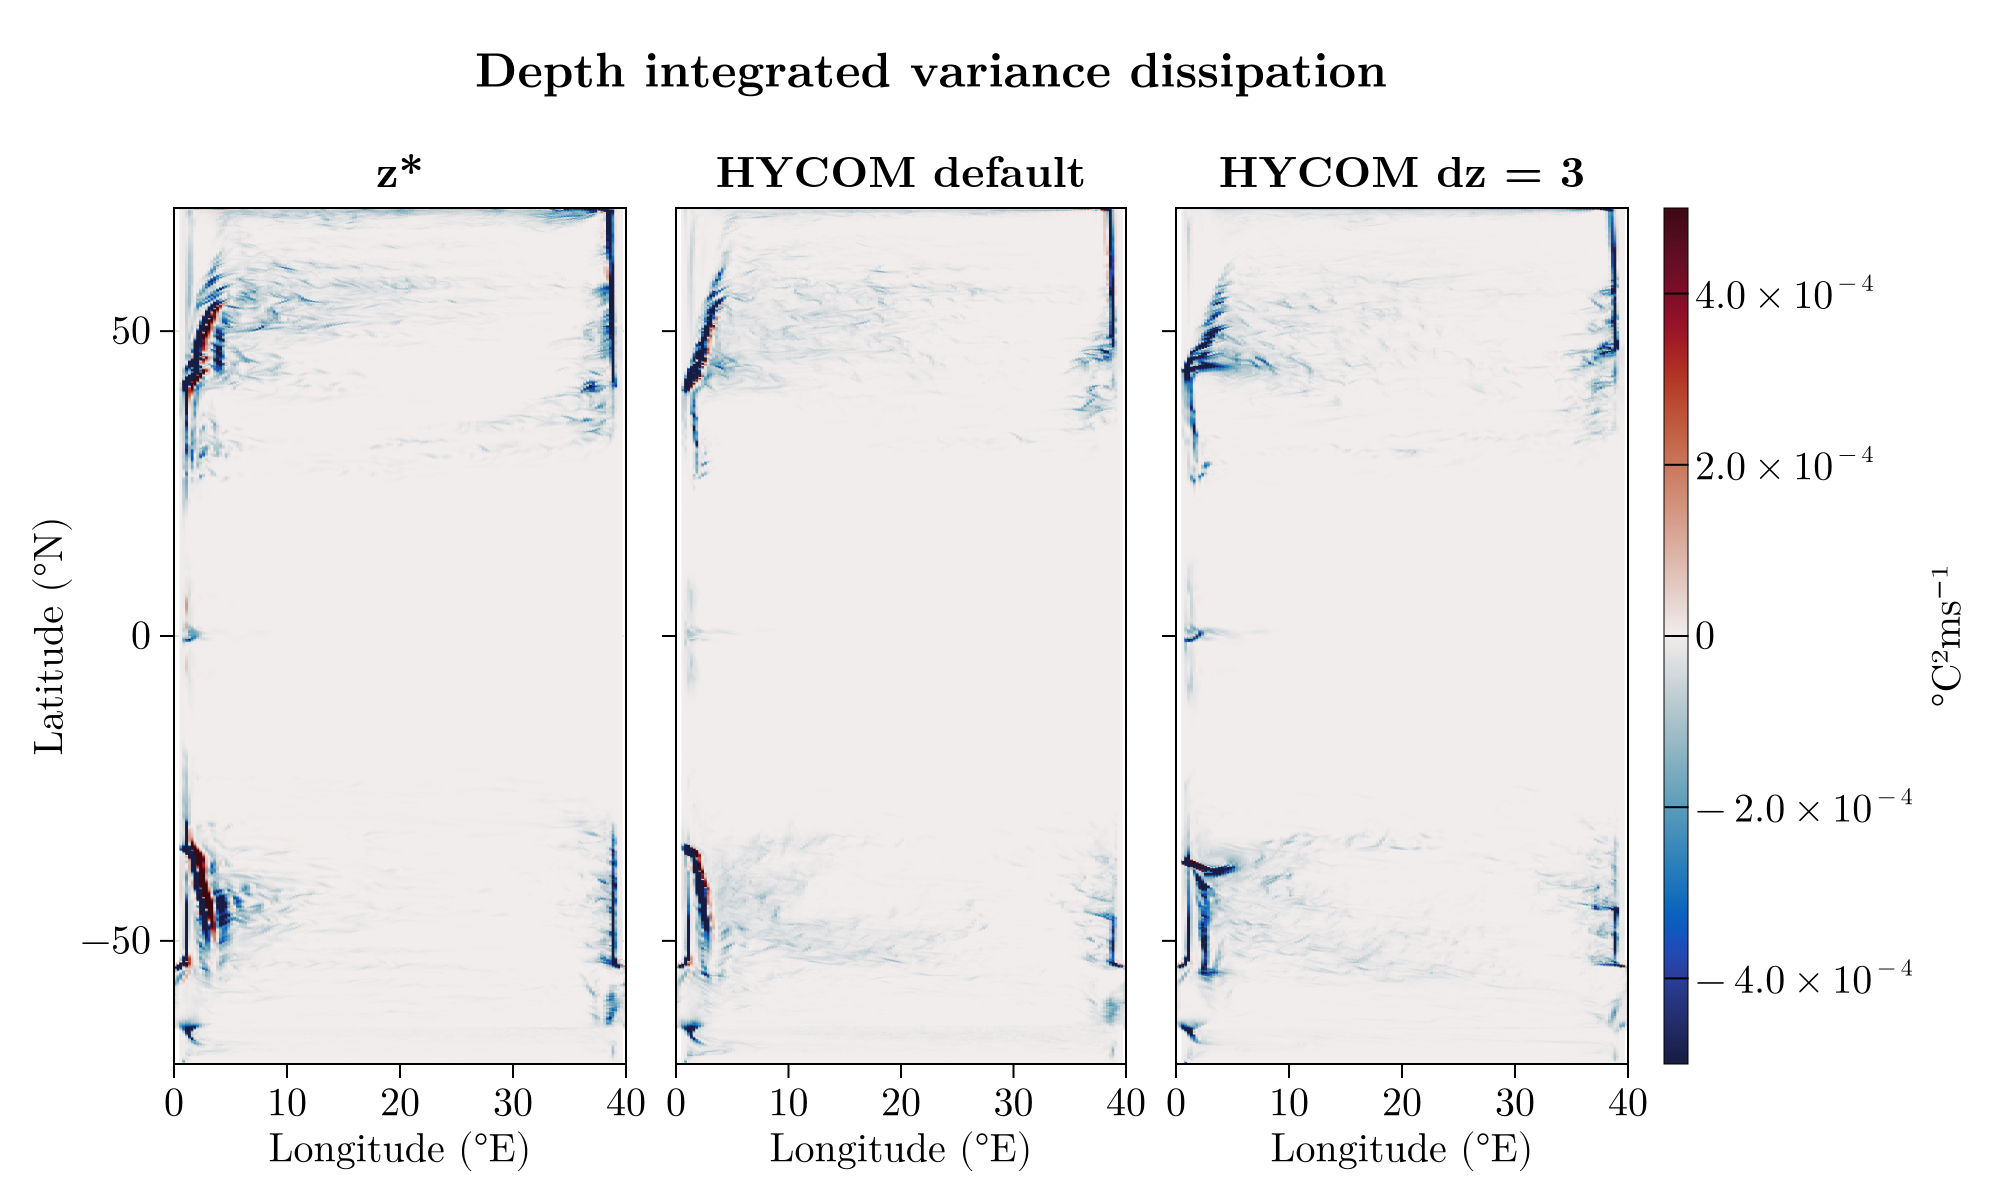

In [11]:
fig = Figure(size = (1000, 600))

colorrange = (-5e-4, 5e-4)
colormap = :balance
ax_zstar = Axis(fig[1, 1], xlabel = "Longitude (°E)", ylabel = "Latitude (°N)", title = "z*")
hm = heatmap!(ax_zstar, crs_zstar.lonh, crs_zstar.lath, ∫nm_zstar; colorrange, colormap)

ax_hycomd = Axis(fig[1, 2], xlabel = "Longitude (°E)", ylabel = "Latitude (°N)", title = "HYCOM default")
hideydecorations!(ax_hycomd, ticks = false)
hm = heatmap!(ax_hycomd, crs_hycom.lonh, crs_hycom.lath, ∫nm_hycom_d; colorrange, colormap)

ax_hycomdz3 = Axis(fig[1, 3], xlabel = "Longitude (°E)", ylabel = "Latitude (°N)", title = "HYCOM dz = 3")
hideydecorations!(ax_hycomdz3, ticks = false)
hm = heatmap!(ax_hycomdz3, crs_hycom.lonh, crs_hycom.lath, ∫nm_hycom_dz3; colorrange, colormap)

linkyaxes!(ax_zstar, ax_hycomd)
linkyaxes!(ax_zstar, ax_hycomdz3)

Colorbar(fig[1, 4], hm, label = "°C²ms⁻¹", tickformat = latex_format)

Label(fig[0, :], "Depth integrated variance dissipation", fontsize = 24, font = :bold)

fig

In [7]:
save("depth_int_variance_dissipation.png", fig)

### Zonal mean

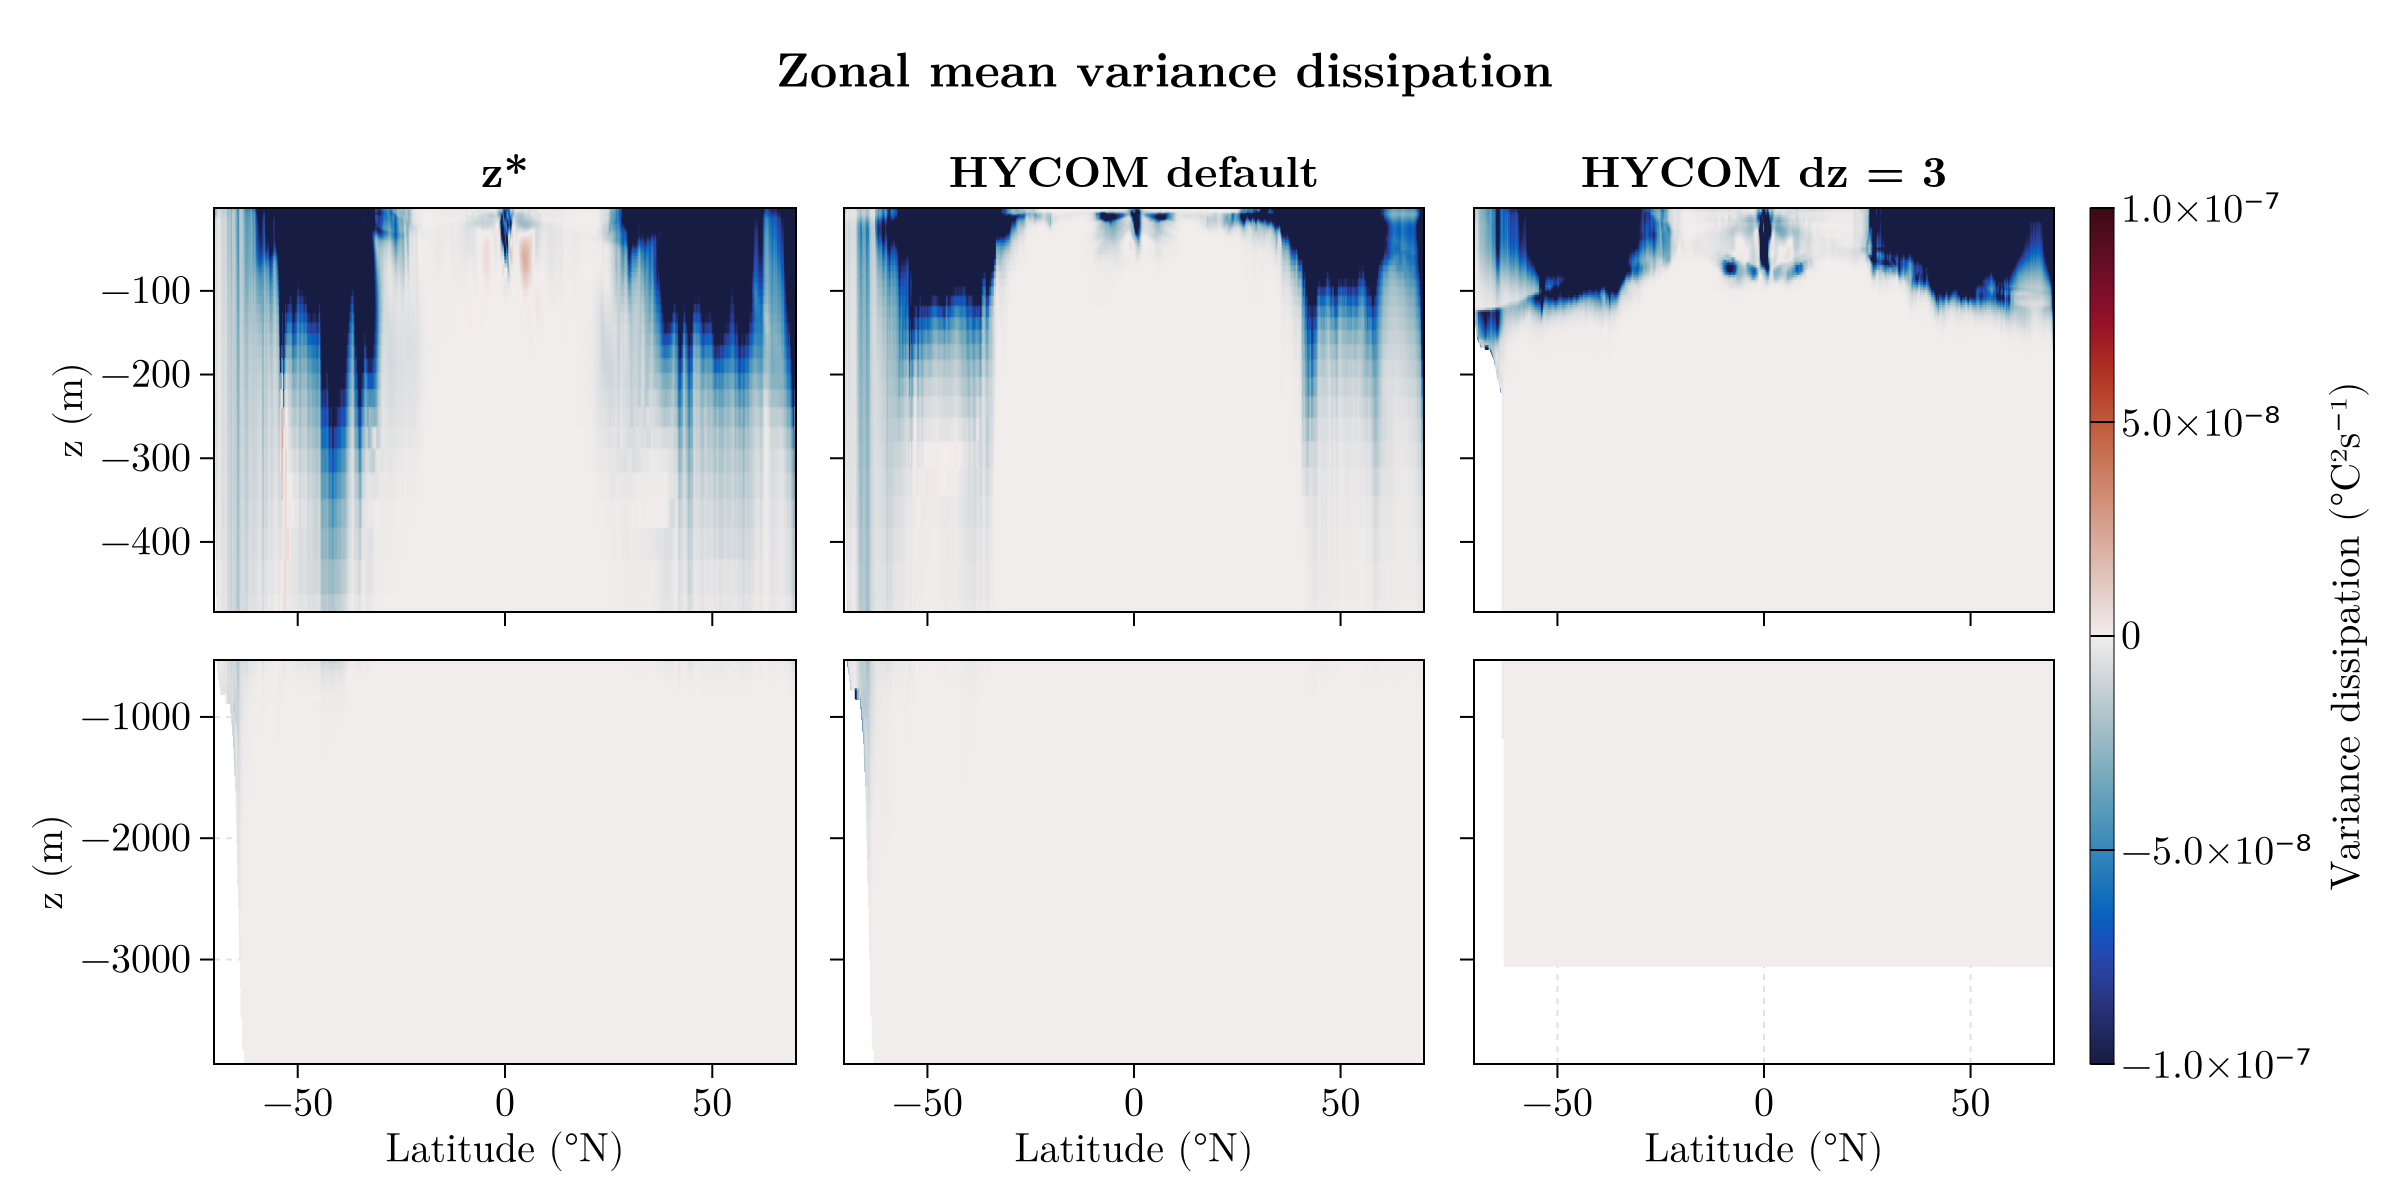

In [8]:
fig = Figure(size = (1200, 600))

colormap = :balance
colorrange = (-1e-7, 1e-7)
top = 1:50
bot = top[end]+1:75

# hycom default top
axtop_hd = Axis(fig[1, 2], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "HYCOM default")
hidexdecorations!(axtop_hd, ticks = false)
hideydecorations!(axtop_hd, ticks = false)
hm = heatmap!(axtop_hd, crs_hycom.lath, crs_hycom.zl, zm_var_diss_hycom_d; colorrange, colormap)
# hycom default top
axbot_hd = Axis(fig[2, 2], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot_hd, crs_hycom.lath, crs_hycom.zl, zm_var_diss_hycom_d; colorrange, colormap)
hideydecorations!(axbot_hd, ticks = false)

axtop = Axis(fig[1, 3], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "HYCOM dz = 3")
hideydecorations!(axtop, ticks = false)
hidexdecorations!(axtop, ticks = false)
hm = heatmap!(axtop, crs_hycom.lath, crs_hycom_dz3.zl, zm_var_diss_hycom_dz3; colorrange, colormap)
axbot = Axis(fig[2, 3], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, crs_hycom.lath, crs_hycom_dz3.zl, zm_var_diss_hycom_dz3; colorrange, colormap)
hideydecorations!(axbot, ticks = false)
# ylims!(axbot, crs_hycom.zl[bot[end]], crs_hycom.zl[bot[1]])

# zstar top, plotted last for ylims
axtop_zs = Axis(fig[1, 1], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "z*")
hm = heatmap!(axtop_zs, crs_zstar.lath, crs_zstar.zl, zm_var_diss_zstar; colorrange, colormap)
ylims!(axtop_zs, crs_zstar.zl[top[end]], crs_zstar.zl[top[1]])
hidexdecorations!(axtop_zs, ticks = false)
# zstar bottom
axbot_zs = Axis(fig[2, 1], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot_zs, crs_zstar.lath, crs_zstar.zl, zm_var_diss_zstar; colorrange, colormap)
ylims!(axbot_zs, crs_zstar.zl[bot[end]], crs_zstar.zl[bot[1]])

linkyaxes!(axtop_zs, axtop_hd, axtop)
linkyaxes!(axbot_zs, axbot_hd, axbot)

Colorbar(fig[:, 4], hm, label = "Variance dissipation (°C²s⁻¹)")

Label(fig[0, :], "Zonal mean variance dissipation", fontsize = 24, font = :bold)

fig

### What is going on with HYCOM dz = 3

It has some numerical mixing occuring where it should not because it is not in the model domain!
Is it plotting/visualisation or something else?
**UPDATE:** almost positive it is plotting/visualisation.

In [ ]:
ds = NCDataset(catalogue["zstar-PPMH3"]["monthly"], maskingvalue = NaN)
h_zstar = mean(nanmean(ds["thkcello"][:, :, :, :], dims = 1), dims = 4)
h_zstar = dropdims(h_zstar, dims = (1, 4))
# h_zstar = log10.(h_zstar)
close(ds)

ds = NCDataset(catalogue[hy_key]["monthly"], maskingvalue = NaN)
h_hycom_d = mean(nanmean(ds["thkcello"][:, :, :, :], dims = 1), dims = 4)
h_hycom_d = dropdims(h_hycom_d, dims = (1, 4))
# h_hycom_d = log10.(h_hycom_d)
close(ds)

# Thickness for checking
ds = NCDataset(catalogue[hy_key]["monthly"], maskingvalue = NaN)
h_hycom_dz3 = mean(nanmean(ds["thkcello"][:, :, :, :], dims = 1), dims = 4)
h_hycom_dz3 = dropdims(h_hycom_dz3, dims = (1, 4))
# h_hycom_dz3 = log10.(h_hycom_dz3)
close(ds)

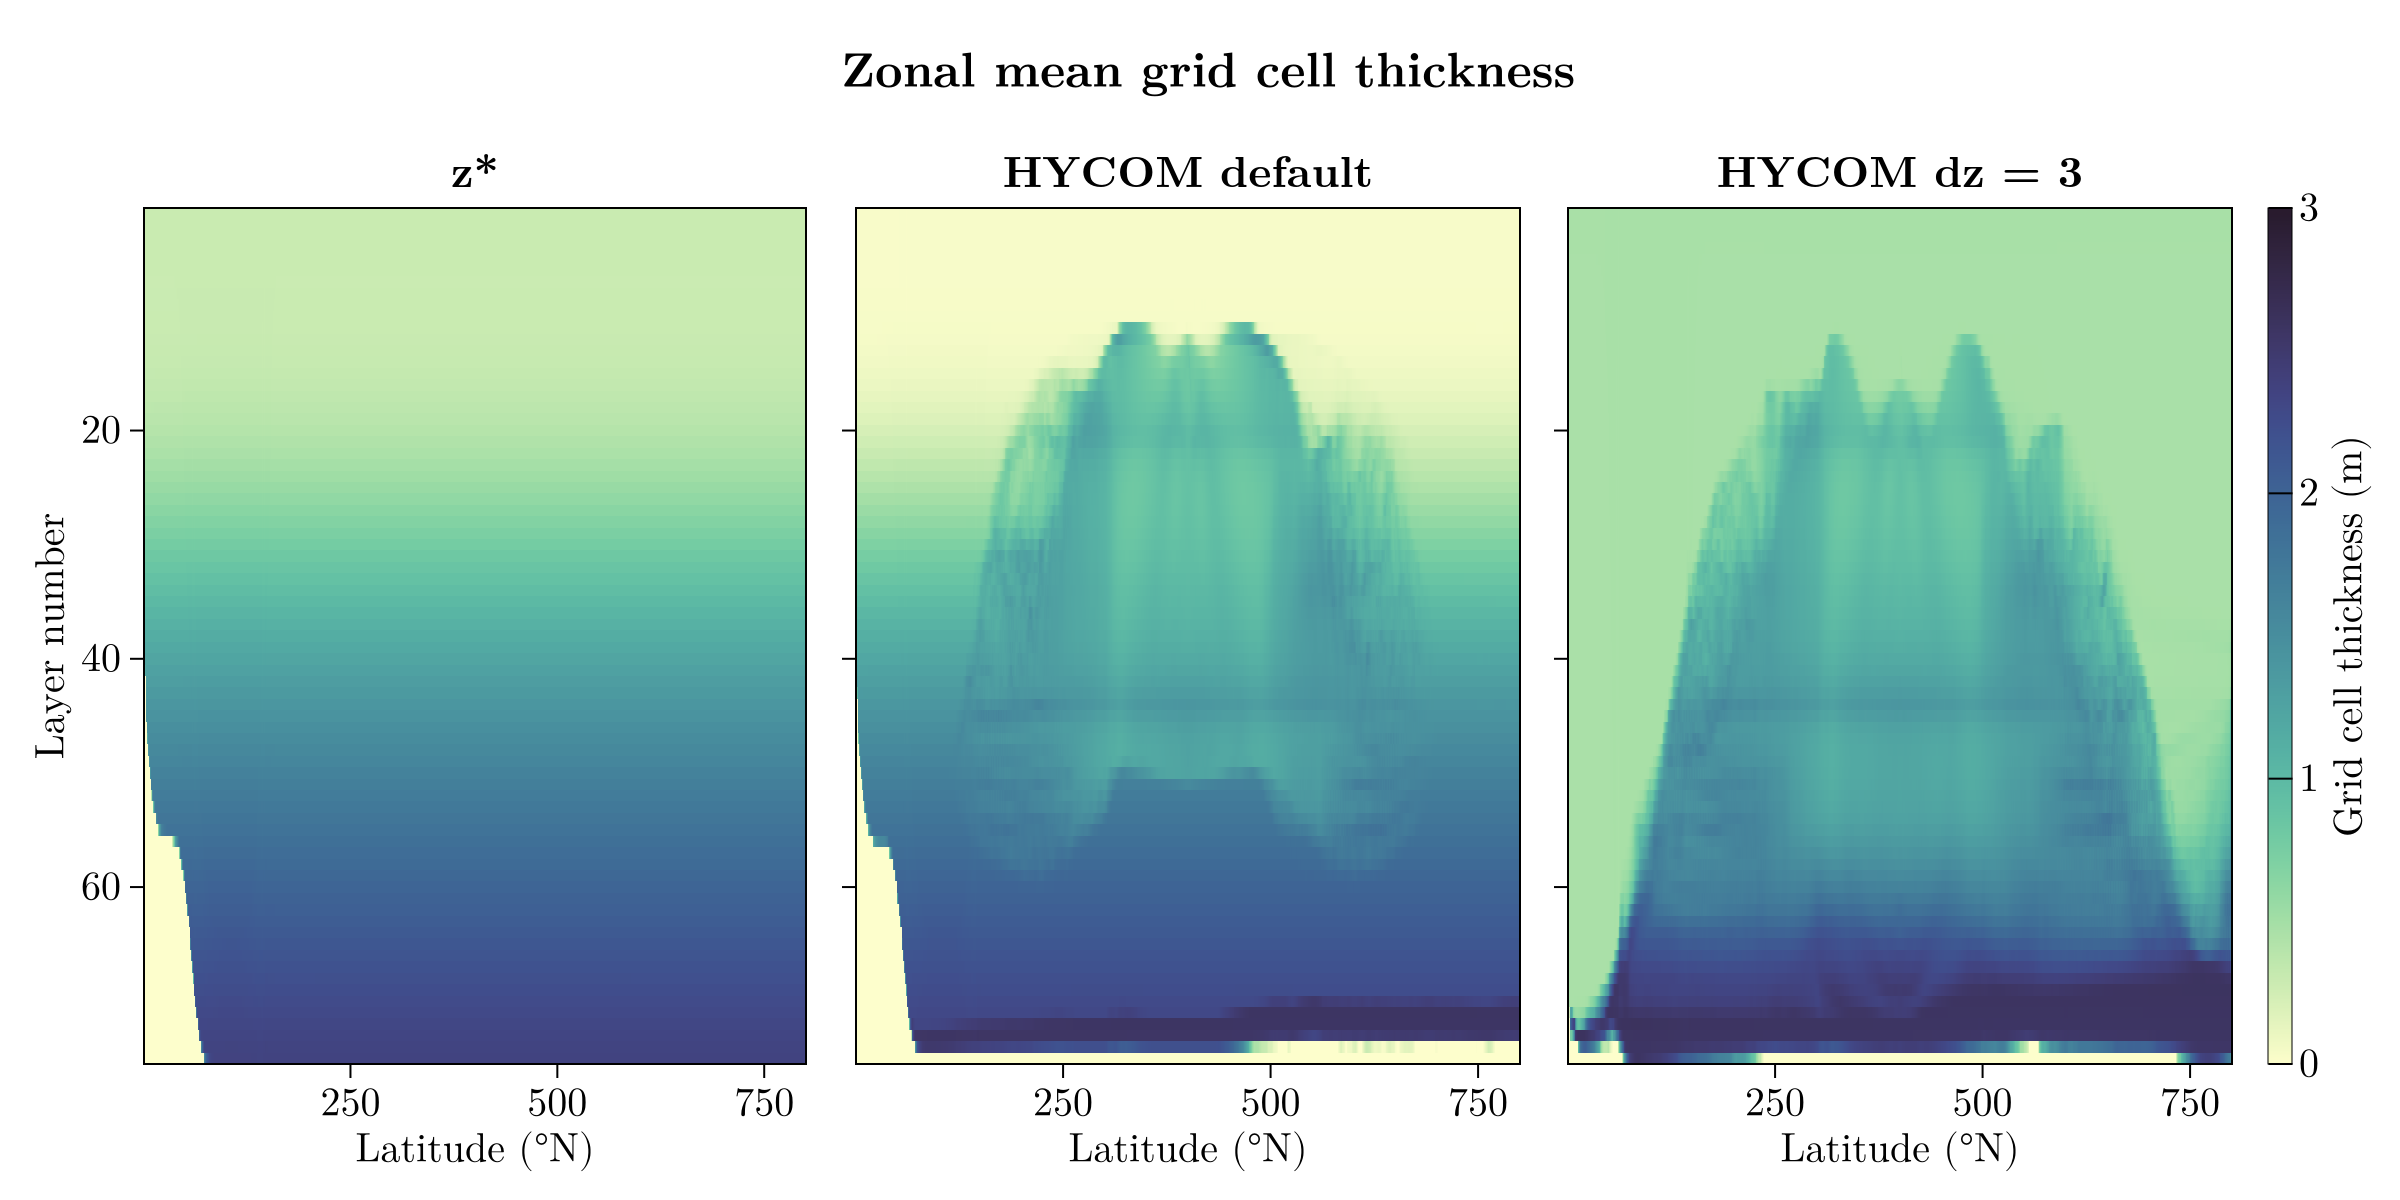

In [41]:
fig = Figure(size = (1200, 600))

## thickness
colormap = :deep
colorrange = (0, 3)
top = 1:75

axtop = Axis(fig[1, 1], xlabel = "Latitude (°N)", ylabel = "Layer number", title = "z*", yreversed = true)
hm = heatmap!(axtop, log10.(h_zstar); colorrange, colormap)

axtop = Axis(fig[1, 2], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "HYCOM default", yreversed = true)
hideydecorations!(axtop, ticks = false)
hm = heatmap!(axtop, log10.(h_hycom_d); colorrange, colormap)


axtop = Axis(fig[1, 3], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "HYCOM dz = 3", yreversed = true)
hideydecorations!(axtop, ticks = false)
hm = heatmap!(axtop, log10.(h_hycom_dz3); colorrange, colormap)

Colorbar(fig[:, 4], hm, label = "Grid cell thickness (m)")

Label(fig[0, :], "Zonal mean grid cell thickness ", fontsize = 24, font = :bold)

# ## Layer numerical mixing
# colormap = :balance
# colorrange = (-1e-7, 1e-7)
# top = 1:75

# axtop = Axis(fig[1, 1], xlabel = "Latitude (°N)", ylabel = "Layer number", title = "z*", yreversed = true)
# hm = heatmap!(axtop, zm_var_diss_zstar[:, top]; colorrange, colormap)

# axtop = Axis(fig[1, 2], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "HYCOM default", yreversed = true)
# hideydecorations!(axtop, ticks = false)
# hm = heatmap!(axtop, zm_var_diss_hycom_d[:, top]; colorrange, colormap)


# axtop = Axis(fig[1, 3], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "HYCOM dz = 3", yreversed = true)
# hideydecorations!(axtop, ticks = false)
# hm = heatmap!(axtop, zm_var_diss_hycom_dz3[:, top]; colorrange, colormap)

# Colorbar(fig[:, 4], hm, label = "Grid cell thickness (m)")

# Label(fig[0, :], "Zonally averaged numerical mixing", fontsize = 24, font = :bold)


fig

The thickness does not look too bad in the middle of the domain but the mask is not there!
That does explain what we are seeing but it does not explain to me why there is a consistent `dz=3` where there is no domain as specified by `topog.nc`.

The only other settings that I overrode in `MOM_override` were:
```
#override MAXIMUM_INT_DEPTH_CONFIG = NONE
#override MAX_LAYER_THICKNESS_CONFIG = NONE
```
Before playing around with the hycom density profile need to turn these off to see what happens.

`output002` has these overrides removed, but the domain is still not being respected.
It may be that we cannot see the topography because it is in one, very thick, vertical grid cell.
Can see from the thickness in each layer that it is ~3m till around layer 70 which would take us to ~210m.
At this depth we would see no topography so it is possible this again comes down to a visualisation problem.
Given how the rest of the figures look, there is a good chance this is it, so have to compute it from the native layer grid but plot it in a way that works across all grids.
Maybe find out the depth at a given layer, from the thickness, then figure out a plotting coordinate from that.
Though of course I first need to check this.

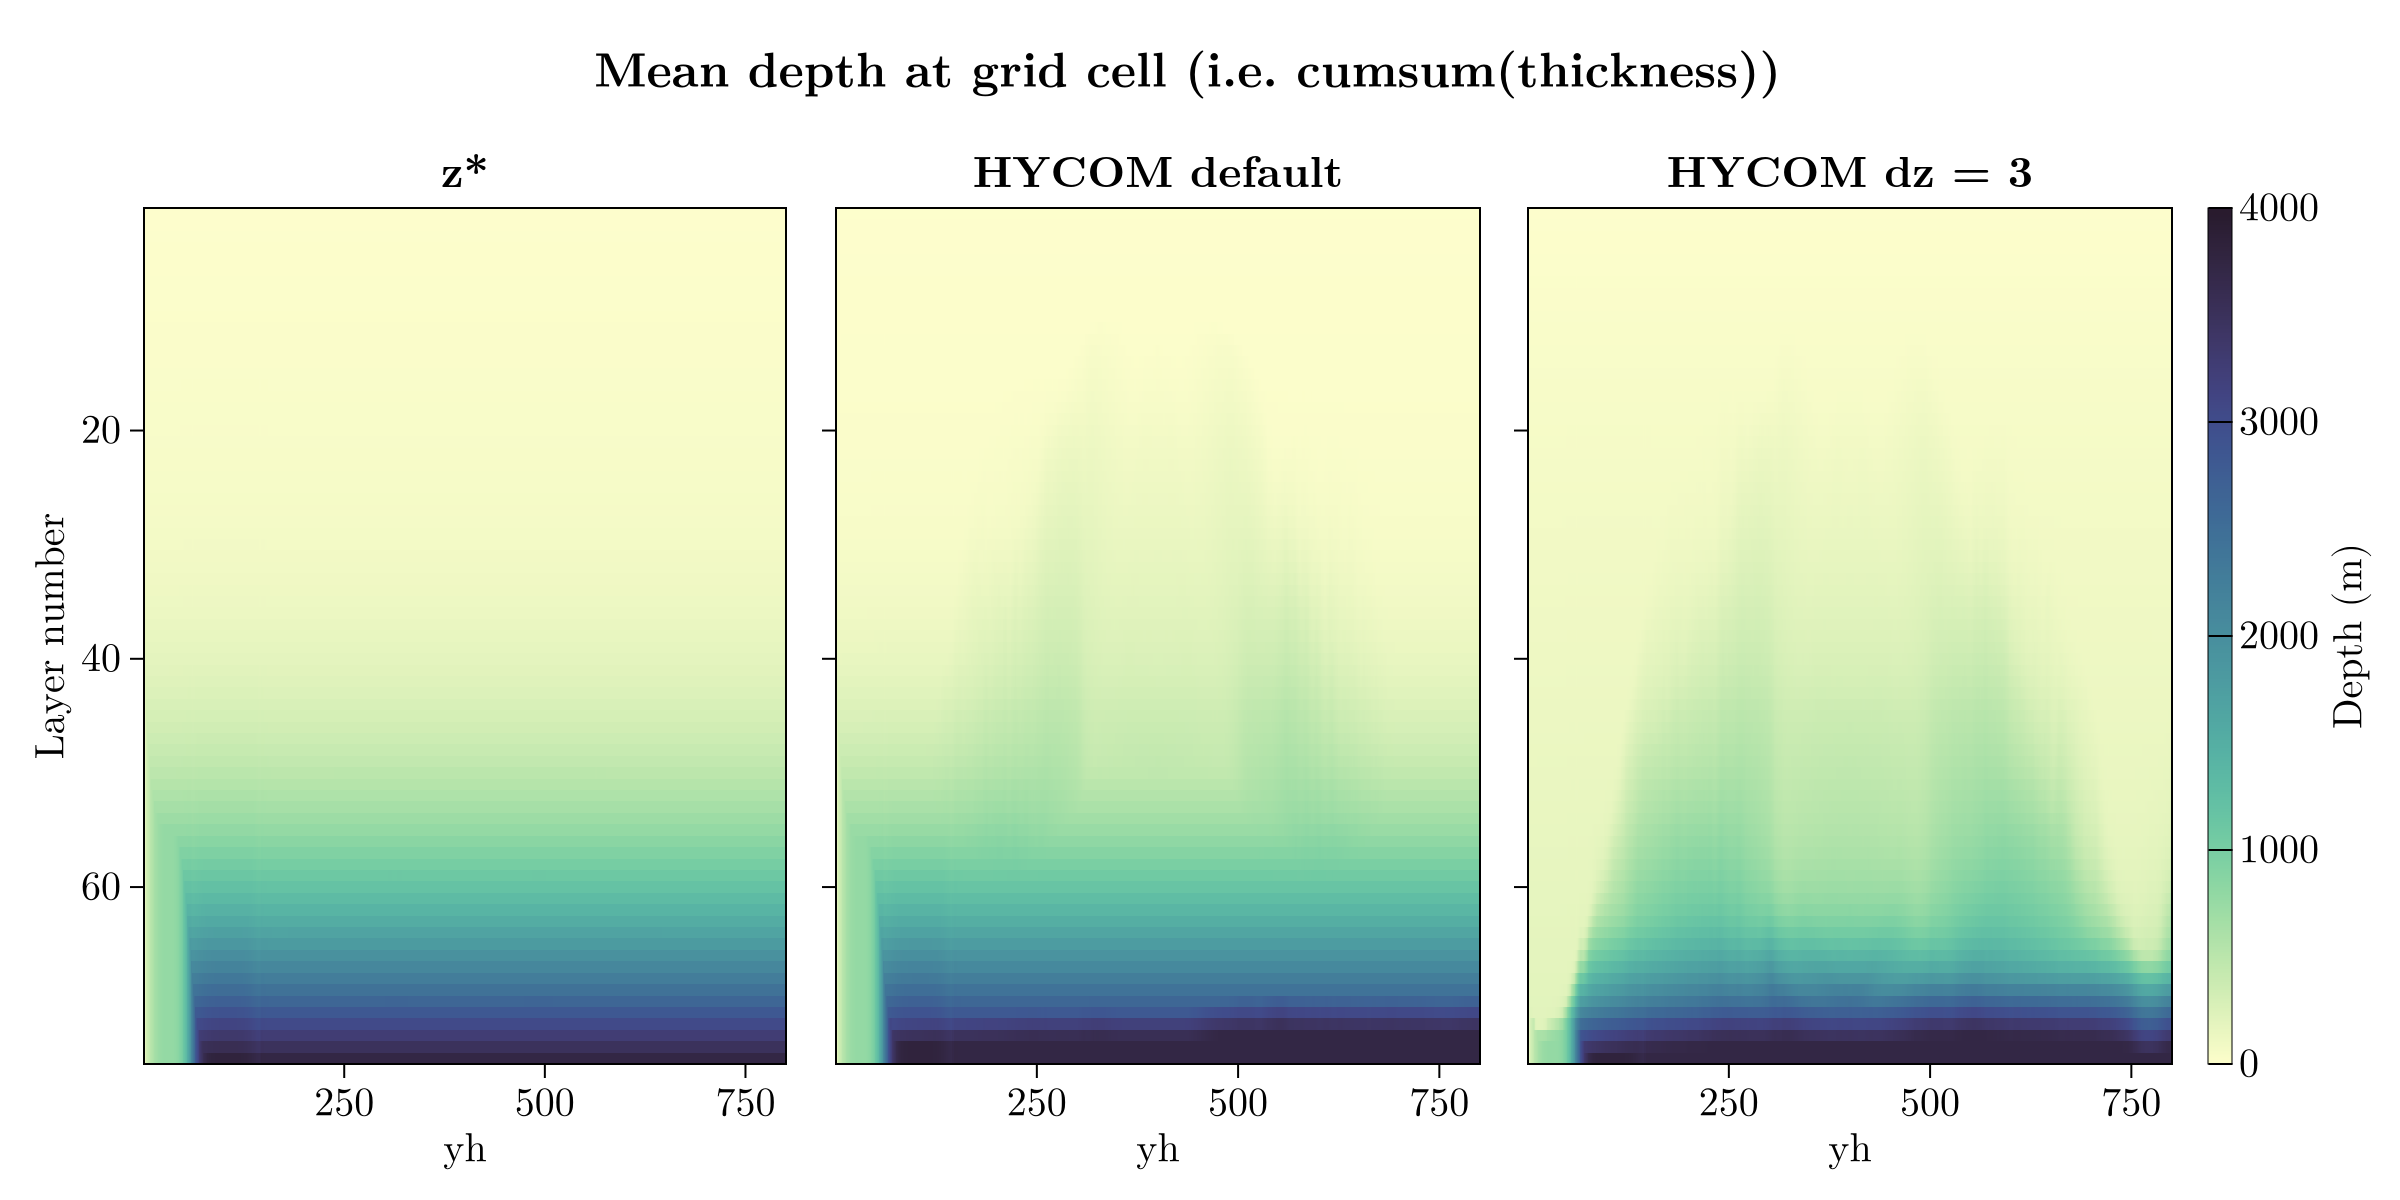

In [69]:
fig = Figure(size = (1200, 600))

## thickness
colormap = :deep
colorrange = (0, 4000)
top = 1:75

depth_zstar = cumsum(h_zstar, dims = 2)
depth_hycom_d = cumsum(h_hycom_d, dims = 2)
depth_hycom_dz3 = cumsum(h_hycom_dz3, dims = 2)

axtop = Axis(fig[1, 1], xlabel = "yh", ylabel = "Layer number", title = "z*", yreversed = true)
hm = heatmap!(axtop, depth_zstar; colorrange, colormap)

axtop = Axis(fig[1, 2], xlabel = "yh", ylabel = "z (m)", title = "HYCOM default", yreversed = true)
hideydecorations!(axtop, ticks = false)
hm = heatmap!(axtop, depth_hycom_d; colorrange, colormap)

axtop = Axis(fig[1, 3], xlabel = "yh", ylabel = "z (m)", title = "HYCOM dz = 3", yreversed = true)
hideydecorations!(axtop, ticks = false)
hm = heatmap!(axtop, depth_hycom_dz3; colorrange, colormap)

Colorbar(fig[:, 4], hm, label = "Depth (m)")

Label(fig[0, :], "Mean depth at grid cell (i.e. cumsum(thickness))", fontsize = 24, font = :bold)

fig

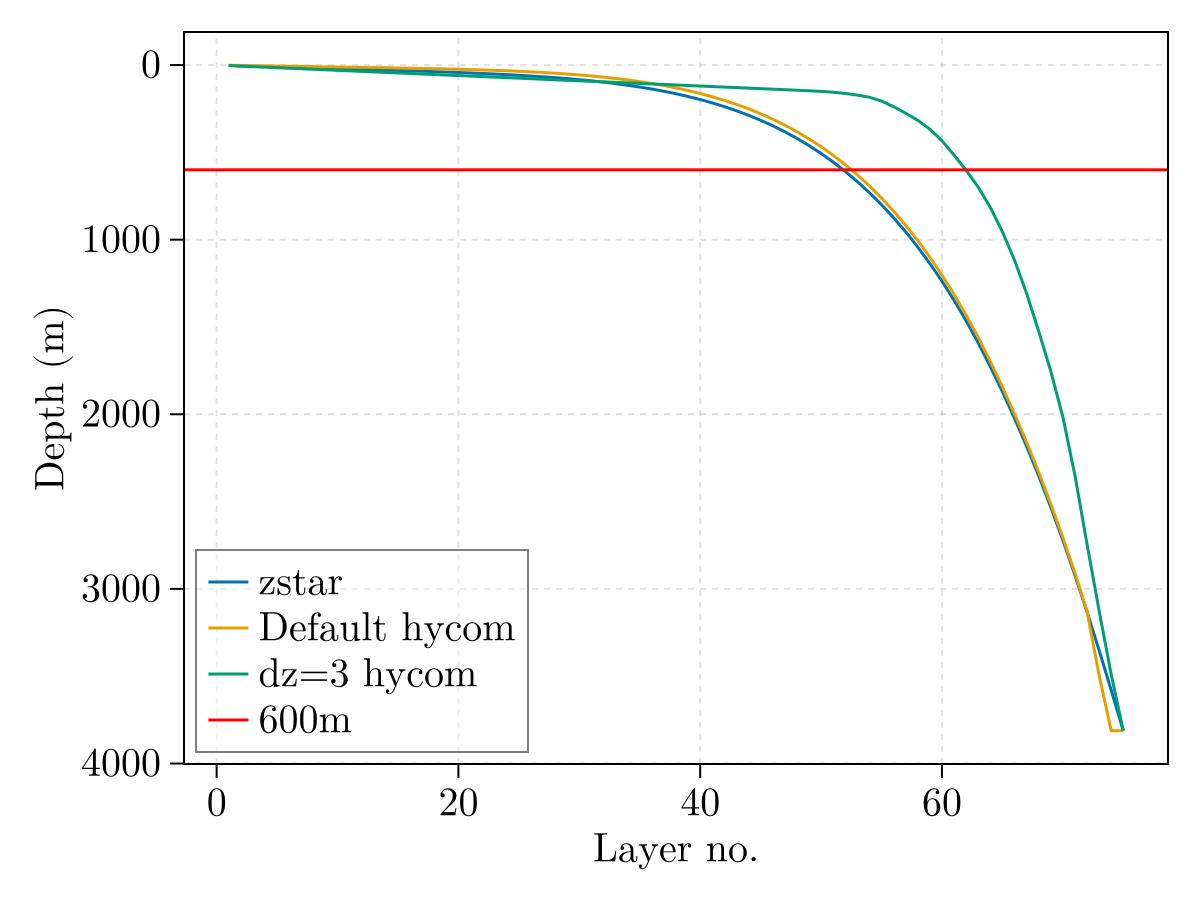

In [70]:
lat_idx = 100

fig, ax = lines(depth_zstar[lat_idx, :], label = "zstar")
lines!(ax, depth_hycom_d[lat_idx, :], label = "Default hycom")
lines!(ax, depth_hycom_dz3[lat_idx, :], label = "dz=3 hycom")
hlines!(ax, 600, color = :red, label = "600m")
ax.xlabel = "Layer no."
ax.ylabel = "Depth (m)"
ax.yreversed = true
axislegend(ax, position = :lb)
fig

Can see here over one layer there is an approximately 400m depth change.
This suggests that everything may be as it should just that plotting as is is not guaranteed to show things in a digestible manner.
And because the default hycom uses the same star profile when it reverts to zstar, as it does near the topography, there is good agreement.
This also means that some of the earlier plots I produced where the ocean seemed to be truncated, may not have been wrong just not well repsented because there was a very, *very* thick layer in the deeper ocean. 

Upside, this seems to be what is going on. Just need to figure out best way to pot things for comparison because in the zonally averaged numerical mixing plots as they currently are, the depth axis does not match the depth at which the numerical mixing is occuring at.
Need to plot things at approximately the depth they take place at is the point.

## Numerical mixing on diagnostic z grid

In [50]:
ds = NCDataset(catalogue["hycom-default-PPMH3"]["monthlyz"], maskingvalue = NaN)
T_advp = nanmean(ds["T_advection_scheme_variance_production"][:, :, :, :], dim = (1, 4))
xh = ds["xh"][:]
yh = ds["yh"][:]
zl = -ds["z_l"][:]
Δz = diff(ds["z_i"][:])
close(ds)

for i ∈ axes(T_advp, 1)
    T_advp[i, :] ./= Δz
end

# hycom default
hy_key = "hycom-default-PPMH3"
crs_hycom = get_geo_coords(catalogue[hy_key]["static"], catalogue[hy_key]["vc"])

zm_var_diss_hycom_d = zonal_variance_dissipation(catalogue[hy_key]["monthlyz"])
zm_var_diss_hycom_d = dropdims(zm_var_diss_hycom_d, dims = (1, 4))

nothing

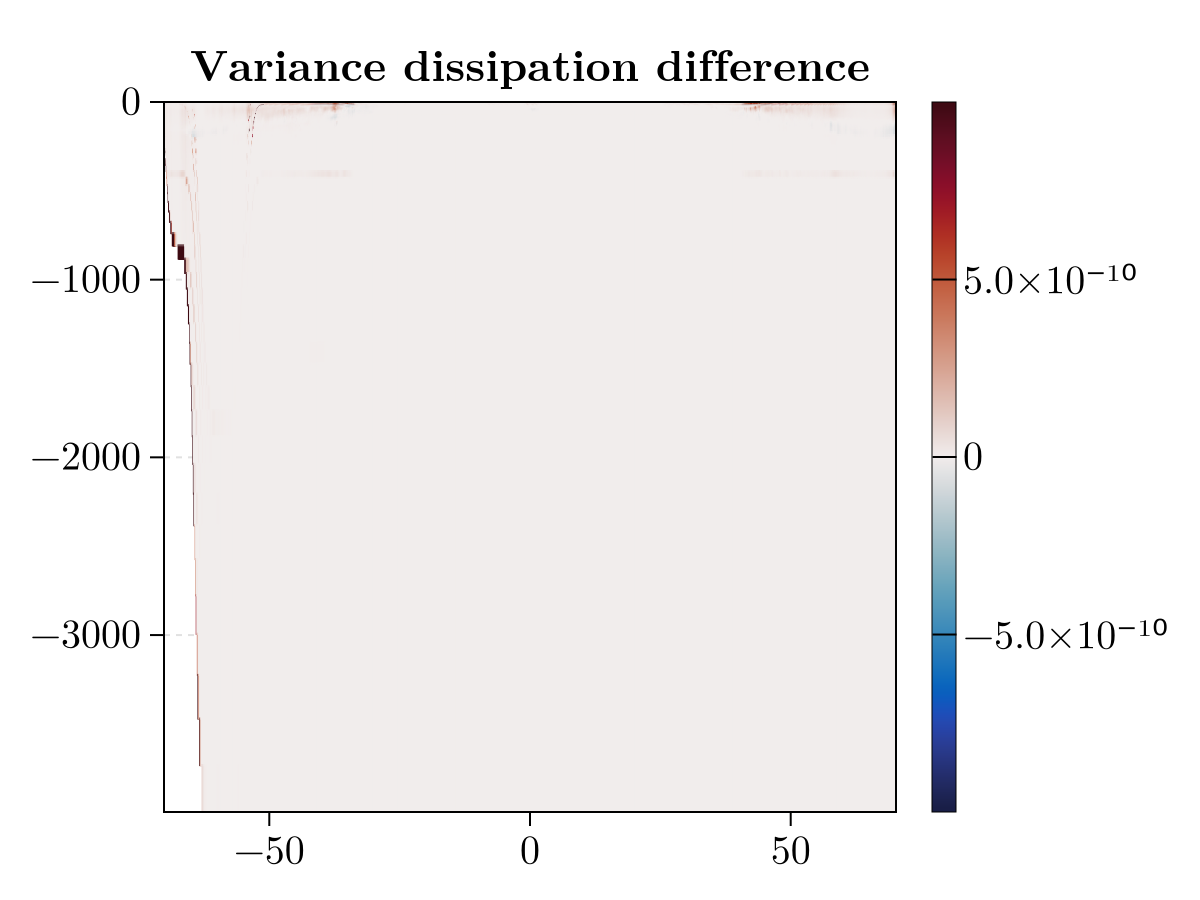

In [57]:
fig, ax, hm = heatmap(yh, zl, T_advp .- zm_var_diss_hycom_d, colormap = :balance, colorrange = (-1e-9, 1e-9))
ax.title = "Variance dissipation difference"
Colorbar(fig[1,2], hm)
fig

Numerical mixing is basically equal when calculating with thickness or $\Delta z$ from interface heights.
However, the simplest thing to do is save thickness on the z grid.

## Thickness vs $\Delta z$

Are these the same on diagnostic grids?

In [35]:
ds = NCDataset(catalogue["hycom-default-PPMH3"]["monthlyz"], maskingvalue = NaN)
h = ds["thkcello"][:, :, :, :]
zl = -ds["z_l"][:]
Δz = diff(ds["z_i"][:])
close(ds)

closed Dataset

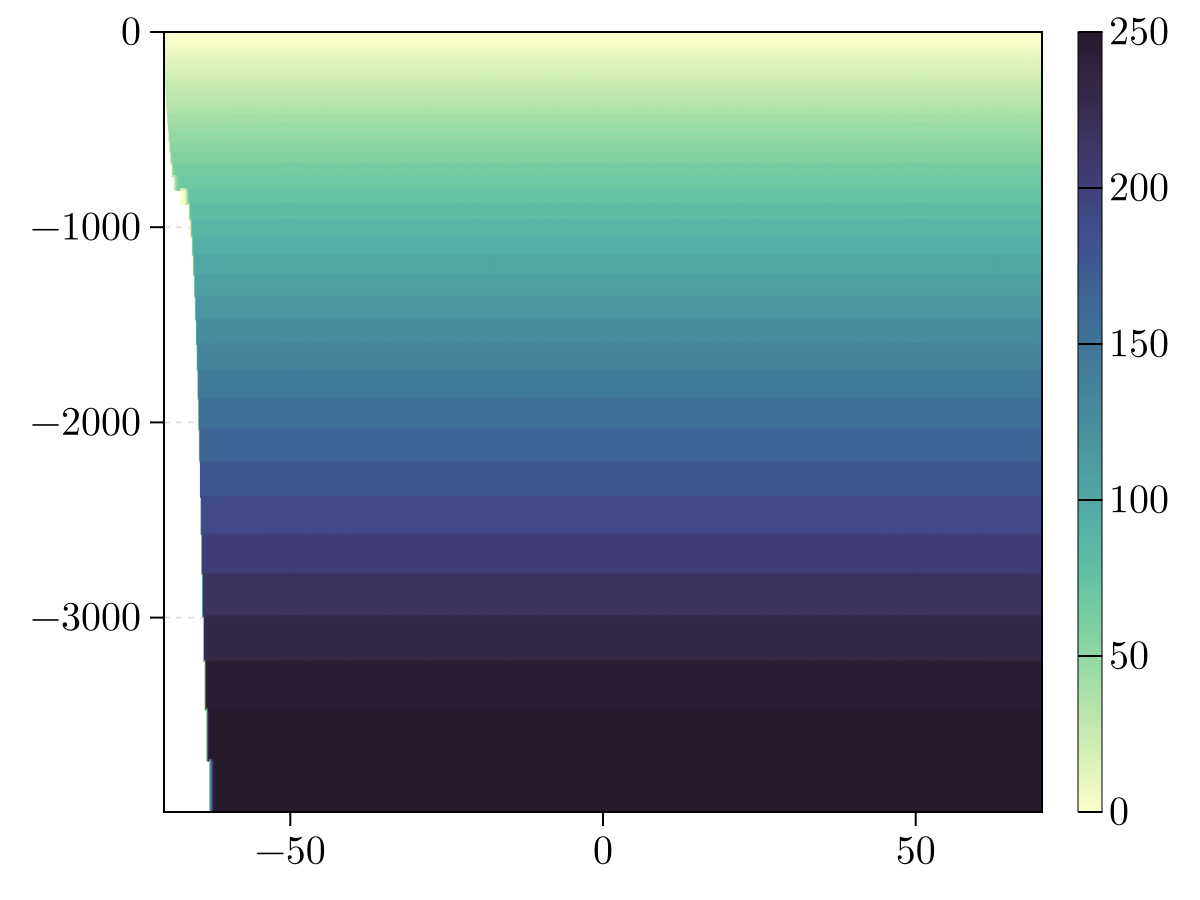

In [23]:
fig, ax, hm = heatmap(yh, zl, h[80, :, :, end], colormap = :deep, colorrange = (0, 2.5e2))
Colorbar(fig[1,2], hm)
fig

Not especially revealing looking at a snapshot but looks like same thickness at each depth.

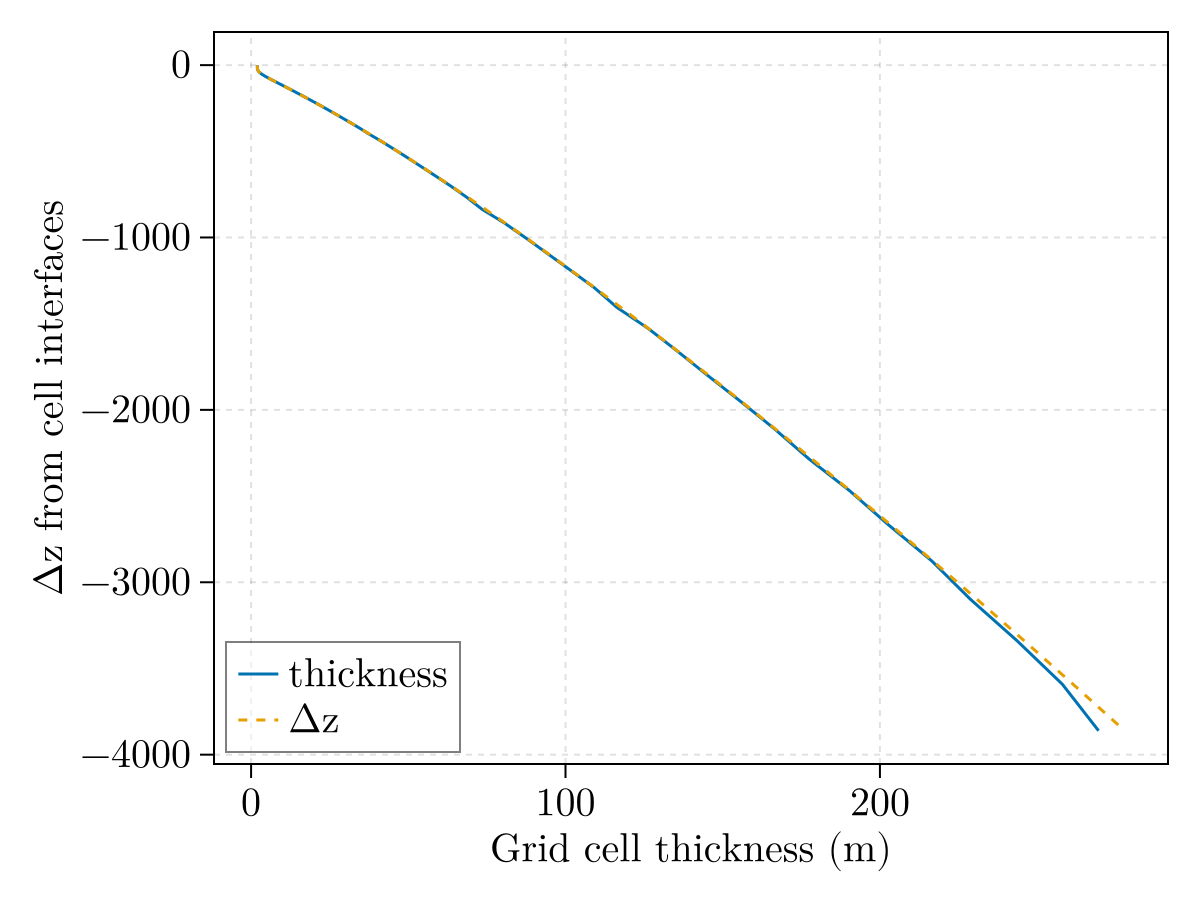

In [40]:
h_mean = nanmean(h, dim = (1, 2, 4))
fig, ax = lines(h_mean, zl, label = "thickness")
lines!(ax, Δz, zl, label = "Δz", linestyle = :dash)
axislegend(ax, position = :lb)
ax.xlabel = "Grid cell thickness (m)"
ax.ylabel = "Δz from cell interfaces"
fig

## Numerical mixing scaled by square of vertical gradient

In [8]:
nm_zstar_diff = zonal_numerical_mixing_diffusivity(catalogue["zstar-PPMH3"]["monthly"])
nm_zstar_diff = dropdims(nm_zstar_diff, dims = (1, 4))
nm_zstar_diff = abs.(nm_zstar_diff)
replace!(nm_zstar_diff, 0 => eps())
# nm_zstar_diff = log10.(abs.(nm_zstar_diff))
# replace!(nm_zstar_diff, -Inf => 0)

nm_hycom_diff = zonal_numerical_mixing_diffusivity(catalogue[hy_key]["monthly"])
nm_hycom_diff = dropdims(nm_hycom_diff, dims = (1, 4))
nm_hycom_diff = abs.(nm_hycom_diff)
replace!(nm_hycom_diff, 0 => eps())
# nm_hycom_diff = log10.(abs.(nm_hycom_diff))
# replace!(nm_hycom_diff, -Inf => 0)

nothing

# Suggested to plot this on a log scale. To do so will have to take absolute value as there are some negative values.

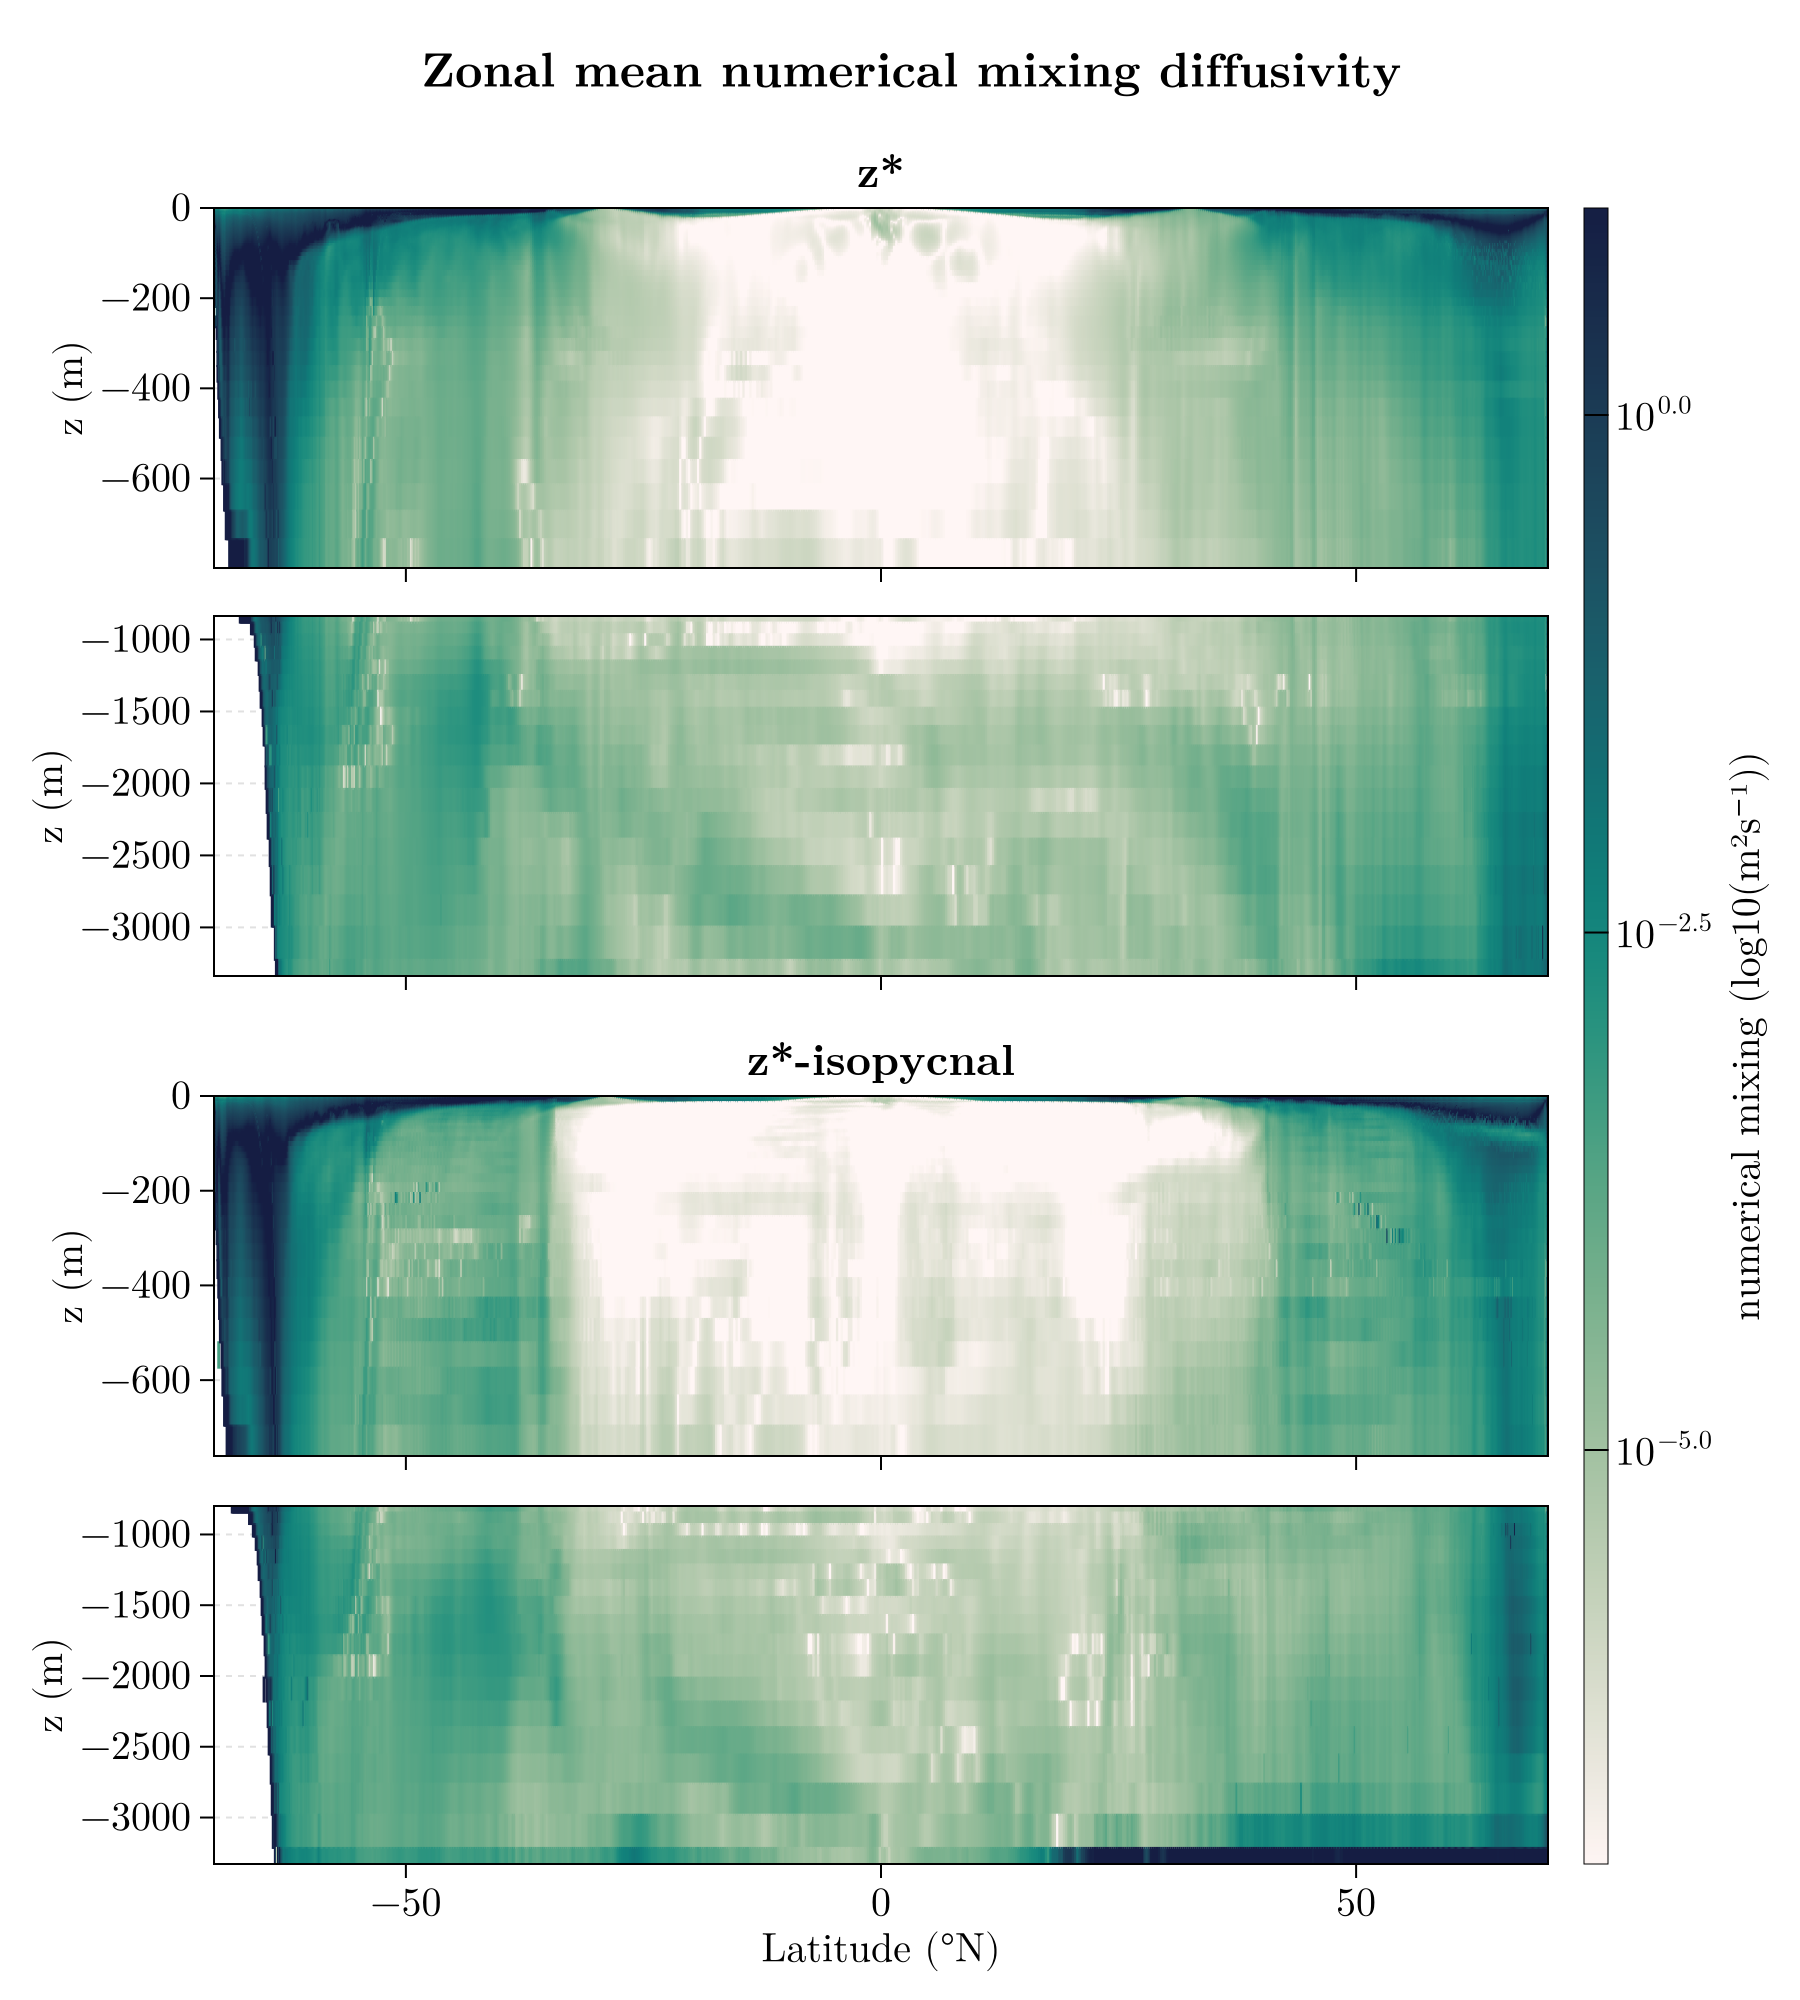

In [9]:
fig = Figure(size = (900, 1000))

colormap = :tempo

top = 1:55
bot = top[end]+1:73
    
colorrange = (1e-7, 1e1)
colorscale = log10

axtop = Axis(fig[1, 1], xlabel = "Latitude (°N)", ylabel = "z (m)", title = title = "z*")
hm = heatmap!(axtop, crs_zstar.lath, crs_zstar.zl[top], nm_zstar_diff[:, top]; colorrange, colorscale, colormap)
axbot = Axis(fig[2, 1], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, crs_zstar.lath, crs_zstar.zl[bot], nm_zstar_diff[:, bot]; colorrange, colorscale, colormap)
ylims!(axbot, crs_zstar.zl[bot[end]], crs_zstar.zl[bot[1]])

hidexdecorations!(axtop, ticks = false)
hidexdecorations!(axbot, ticks = false)

axtop = Axis(fig[3, 1], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "z*-isopycnal")
hm = heatmap!(axtop, crs_hycom.lath, crs_hycom.zl[top], nm_hycom_diff[:, top]; colorrange, colorscale, colormap)
axbot = Axis(fig[4, 1], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, crs_hycom.lath, crs_hycom.zl[bot], nm_hycom_diff[:, bot]; colorrange, colorscale, colormap)
ylims!(axbot, crs_hycom.zl[bot[end]], crs_hycom.zl[bot[1]])

hidexdecorations!(axtop, ticks = false)

Colorbar(fig[:, 2], hm, label = "numerical mixing (log10(m²s⁻¹))")

Label(fig[0, :], "Zonal mean numerical mixing diffusivity", fontsize = 24, font = :bold)

fig

In [10]:
save("numerical_diffusivity.png", fig)

## Global numerical mixing

Aiming to get an idea of how numerical mixing is contributing to total mixing that is occuring.